In [1]:
import sys, os
import re
import gc
import glob
import pandas as pd
import ast
import itertools
import numpy as np
from pathlib import Path

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
from tqdm.notebook import tqdm

tqdm.pandas()

In [4]:
import warnings
warnings.filterwarnings("ignore")

### Loading package

In [5]:
import sys
from pathlib import Path

here_path = Path().resolve()
repo_path = here_path.parents[1]
sys.path.append(str(repo_path))

In [6]:
import sys
from pathlib import Path

here_path = Path().resolve()
repo_path = here_path.parents[1]
sys.path.append(str(repo_path))

In [7]:
from py.config import Config

cfg = Config()

np.random.seed(cfg.RANDOM_STATE)
cfg.DATA_PATH, cfg.MODEL_PATH

('/media/felipe/DATA21/datasets/', '/media/felipe/DATA21/models/')

### Loading data

In [9]:
DATA_PATH=f"{cfg.DATA_PATH}postcog/"
CSV_PATH = f"{DATA_PATH}/csv/"
THREADS_PROCESSED = f"{CSV_PATH}/topics/{cfg.TOPIC_SEARCH}/"

In [10]:
df = pd.read_csv(f"{THREADS_PROCESSED}Websites_CVE_Threads.csv", sep="\t", low_memory=False)
df

,sitename,board_title,thread_title,thread_id,content,crime_type,cve_codes_list,intent,posttype,cve_unique_list,r_IMG,r_CITING,r_IFRAME,r_LINK,r_CODE,r_ATTACHMENT,r_QUOTE,content_orig
0,Elhacker,Foro Libre,Mi amigo tiene el móvil más seguro de España (...,497141,El campeón dice que su móvil de 3 años de anti...,not criminal,"['cve-2016-5195', 'cve-2015-6636', 'cve-2015-6...",NaN,NaN,"['cve-2015-9012', 'cve-2016-10297', 'cve-2016-...",[],[],[],[],[],[],[],El campeón dice que su móvil de 3 años de anti...
1,XSS Forum,Уязвимости в ПО / Эксплойтинг,Подборка материалов по эксплуатации уязвимосте...,60783,Contents\nBooks\nTechniques\nExploitation\nPro...,not criminal,"['cve', 'cve-', 'cve-2020-28588', 'cve-2018-36...",NaN,NaN,"['cve-2021-32606', 'cve-2017-7616', 'cve-2021-...",[],[],[],[],[],[],[],Contents\nBooks\nTechniques\nExploitation\nPro...
2,Torum,Operating Systems,Danish surveillance system mail multiple vulne...,124,There's include exploit with modules on Metasp...,not criminal,"['cve', 'cve-2015-3183', 'cve-2012-0053', 'cve...",neutral,tutorial,"['cve-2009-1890', 'cve-2013-1862', 'cve-2007-6...",[],[],[],[],[],[],[],There's include exploit with modules on Metasp...
3,Torum,Operating Systems,Linux ver,2279,Linux\n\n2005\n\n CVE-2005-1294\n\n2006\n\n...,not criminal,"['cve-2005-1294', 'cve-2008-0010', 'cve-2008-0...",neutral,tutorial,"['cve-2009-0360', 'cve-2015-1862', 'cve-2010-2...",[],[],[],[],[],[],[],Linux\n\n2005\n\n CVE-2005-1294\n\n2006\n\n...
4,Hack Forums,Beginner Hacking,+Pentesting: Anyone have a list of vulnerable ...,4299925,FAMVEER \n\nI'm not entirely sure if there ar...,not criminal,"['cve-2014-0323', 'cve-2014-0317', 'cve-2014-0...",neutral,infoRequest,"['cve-2013-3866', 'cve-2014-0301', 'cve-2013-3...",['[images/smilies/blackhat.gif]'],['[https://hackforums.net/showthread.php?pid=4...,[],[],['[CVE-2014-0323\nCVE-2014-0317\xa0\xa0\xa0\xa...,[],[],***CITING***[https://hackforums.net/showthread...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6491,lolzteam,Статьи,Как отключить Bluetooth на чужом девайсе.,304405,Доброго времени суток. Сегодня хотел бы расска...,not criminal,"['cve-2017-0781', 'cve-2017-0781', 'cve-2017-0...",NaN,NaN,['cve-2017-0781'],[],[],[],[],[],[],[],Доброго времени суток. Сегодня хотел бы расска...
6492,lolzteam,Статьи,Замечательный Хакинг,322179,"Братаны, я много вкусного принёс.\n\nКоллекция...",not criminal,['cve'],NaN,NaN,['cve'],[],[],[],[],[],[],[],"Братаны, я много вкусного принёс.\n\nКоллекция..."
6493,lolzteam,Статьи,Взламываем компьютер через презентацию.,276932,"Сегодня мы лoманем комп без ""exe""шника.\nДoпус...",not criminal,"['cve-2017-8570', 'cve-2017-8570']",NaN,NaN,['cve-2017-8570'],[],[],[],[],[],[],[],"Сегодня мы лoманем комп без ""exe""шника.\nДoпус..."
6494,lolzteam,Статьи,Word virus .docx,432025,Эксперты компании Menlo Security зафиксировали...,not criminal,"['cve-2017-8570', 'cve-2017-8570']",NaN,NaN,['cve-2017-8570'],[],[],[],[],[],[],[],Эксперты компании Menlo Security зафиксировали...


### Language

In [11]:
from py.nlpToolkit import LanguageProcesser

In [12]:
LANGUAGE_TO_EVAL=["english", "deutsch", "portuguese", "russian", "spanish"]

In [13]:
language_processer = LanguageProcesser(languages_to_eval=LANGUAGE_TO_EVAL,
                                       log=False,
                                        #exclude_pipe=['tagger', 'parser', 'ner']
                                       exclude_pipe=['morphologizer', "parser", "tagger", 'attribute_ruler', "ner"]
                                      )

In [14]:
for index, row in tqdm(df.iterrows()):
    language_processer.detect_language_and_word_list(row["content"])

    df.loc[index, "unique_word_ratio"] = [language_processer.get_language_ratios()]
    df.loc[index, "all_word_ratio"] = [language_processer.get_all_language_ratios()]

    df.loc[index, "lang_detected"] = language_processer.get_detected_language()
    df.loc[index, "lang_ratio"] = language_processer.get_detected_language_ratio()

    df.loc[index, "correct_words_dict"] = list([{"words": language_processer.get_correct_words()}])
    df.loc[index, "incorrect_words_dict"] = list([{"words": language_processer.get_incorrect_words()}])
    #df.loc[index, "words"] = language_processer.get_processed_text()

0it [00:00, ?it/s]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 42.9 MB/s  0:00:00 78.9 MB/s eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 30.0 MB/s  0:00:00 37.3 MB/s eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 66.7 MB/s  0:00:00 eta 0:00:01
✔ Download and installation successfu

In [15]:
df["lang_detected"].value_counts()

lang_detected
english       3228
russian       1967
spanish       1223
not found       53
portuguese      21
deutsch          4
Name: count, dtype: int64

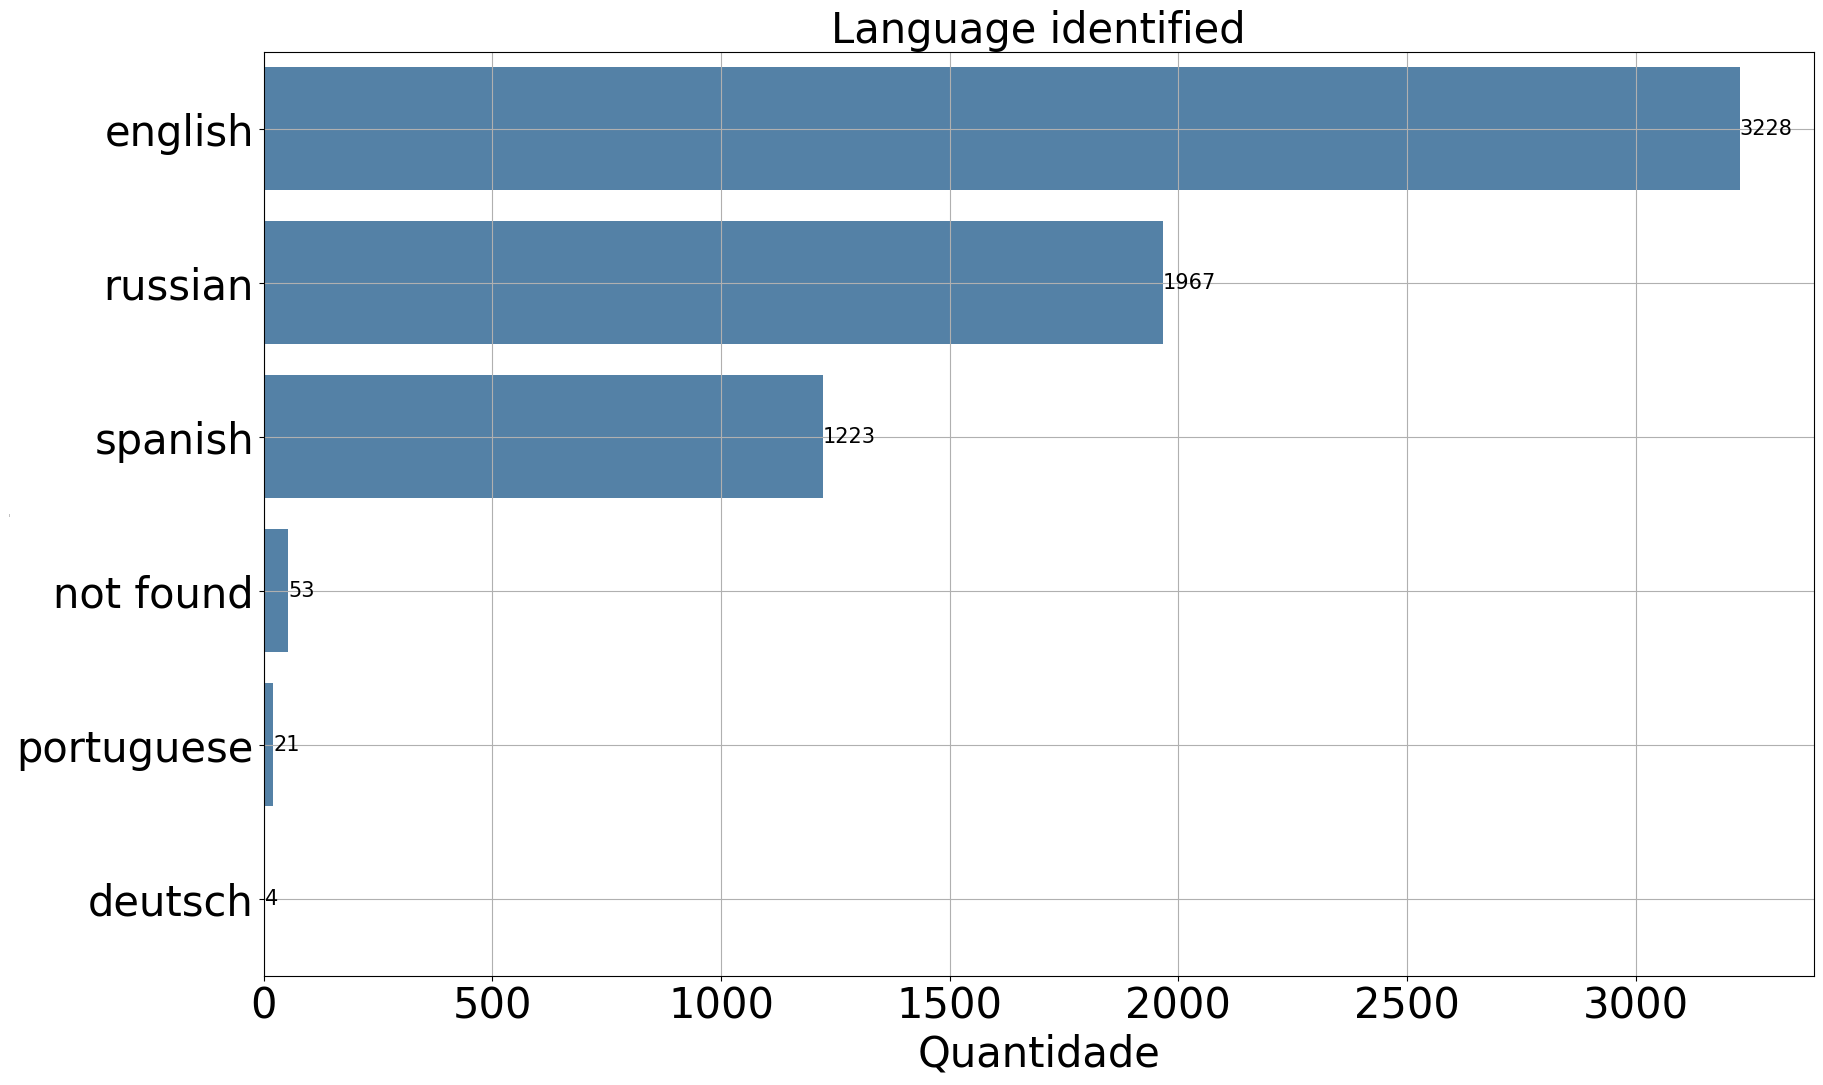

In [16]:
_, ax = plt.subplots(figsize=(20,12), nrows=1, ncols=1, sharex=False, sharey=False)

estado_df = pd.pivot_table(df,
               index=["lang_detected"],
                values=["thread_id"],
                aggfunc={
                    "thread_id":len
                }).reset_index()

sns_fig = sns.barplot(
            data=estado_df,
            x=estado_df.columns[1],
            y=estado_df.columns[0],
            orient="h",
            ax=ax,
            color="steelblue",
            order=estado_df.sort_values(estado_df.columns[1], ascending=False)[estado_df.columns[0]]
           )

sns_fig.set_title(f"Language identified", fontsize=30)
sns_fig.set_ylabel(f"Label", fontsize=0)
sns_fig.set_xlabel('Quantidade', fontsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0, labelsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=30)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=15,rotation=0)

# add a space on y for the annotations
#sns_fig.margins(x=0.1)
ax.grid(True)

In [17]:
df["crime_type"].value_counts()

crime_type
not criminal                                       5552
bots/malware                                        468
access to systems/sql injection                     289
trading credentials                                  82
VPN/proxy/hosting                                    65
DDoS/booting/stress testing                          28
spam related/sharing email addresses/marketing)       6
currency exchange                                     4
identity theft/identity fraud/credit card fraud       1
eWhoring                                              1
Name: count, dtype: int64

In [18]:
for lang in df["lang_detected"].unique():
    print(lang, "\n", df[(df["lang_detected"]==lang) ]["crime_type"].value_counts() )

spanish 
 crime_type
not criminal                       1184
bots/malware                         20
access to systems/sql injection       8
DDoS/booting/stress testing           5
trading credentials                   3
VPN/proxy/hosting                     3
Name: count, dtype: int64
english 
 crime_type
not criminal                                       2431
bots/malware                                        417
access to systems/sql injection                     249
VPN/proxy/hosting                                    54
trading credentials                                  52
DDoS/booting/stress testing                          13
spam related/sharing email addresses/marketing)       6
currency exchange                                     4
identity theft/identity fraud/credit card fraud       1
eWhoring                                              1
Name: count, dtype: int64
russian 
 crime_type
not criminal                       1863
access to systems/sql injection      32
bots/

In [19]:
df[(df["lang_detected"]=="not found") ].sort_values(by="lang_ratio")

,sitename,board_title,thread_title,thread_id,content,crime_type,cve_codes_list,intent,posttype,cve_unique_list,...,r_CODE,r_ATTACHMENT,r_QUOTE,content_orig,unique_word_ratio,all_word_ratio,lang_detected,lang_ratio,correct_words_dict,incorrect_words_dict
480,Hack Forums,Blackhat Training,Port 5555 (ADB),6115147,"CVE-2000-0179, CVE-2013-2347, CVE-2014-2623, C...",not criminal,"['cve-2000-0179', 'cve-2013-2347', 'cve-2014-2...",NaN,NaN,"['cve-2014-2623', 'cve-2019-6005', 'cve-2000-0...",...,[],[],[],"CVE-2000-0179, CVE-2013-2347, CVE-2014-2623, C...","[{'english': 0.0, 'deutsch': 0.0, 'portuguese'...","[{'english': 0.0, 'deutsch': 0.0, 'portuguese'...",not found,0.0,[{'words': []}],[{'words': ['cve']}]
1726,Antichat,Песочница,Повышение привилегий в WP,472378,CVE-2019-8942 & CVE-2019-8943,not criminal,"['cve-2019-8942', 'cve-2019-8943']",NaN,NaN,"['cve-2019-8943', 'cve-2019-8942']",...,[],[],[],CVE-2019-8942 & CVE-2019-8943,"[{'english': 0.0, 'deutsch': 0.0, 'portuguese'...","[{'english': 0.0, 'deutsch': 0.0, 'portuguese'...",not found,0.0,[{'words': []}],[{'words': ['cve']}]
1953,Hack Forums,Computer Protection and Security Alerts,[News] Security Update for Adobe Reader & Acrobat,78717,FAMVEER ... 09-06.html\n\n FAMVEER,not criminal,"['cve-2009-1492', 'cve-2009-1493']",neutral,offerX,"['cve-2009-1492', 'cve-2009-1493']",...,[],[],['Quote:A critical vulnerability has been iden...,***LINK***http://www.adobe.com/support/securit...,"[{'english': 0.0, 'deutsch': 0.0, 'portuguese'...","[{'english': 0.0, 'deutsch': 0.0, 'portuguese'...",not found,0.0,[{'words': []}],[{'words': ['html']}]
2007,Hackers Armies,منتدى الفيروسات,فيروس حاسوب جديد يضرب 350 هدفا في40 دولة حول ا...,48427,"كشف خبراء معهد حماية المعلومات "" كسبرسكي "" الأ...",not criminal,"['cve-2012-0158', 'cve-2010-3333']",NaN,NaN,"['cve-2010-3333', 'cve-2012-0158']",...,[],[],[],"كشف خبراء معهد حماية المعلومات "" كسبرسكي "" الأ...","[{'english': 0.0, 'deutsch': 0.0, 'portuguese'...","[{'english': 0.0, 'deutsch': 0.0, 'portuguese'...",not found,0.0,[{'words': []}],"[{'words': ['cve', 'nettraveler']}]"
2091,Hack Forums,Website Hacking,What is this x)?,4541856,FAMVEER,not criminal,"['cve', 'cve', 'cve-2010-0425', 'cve', 'cve', ...",neutral,offerX,"['cve-2010-0425', 'cve']",...,[],[],[],***LINK***http://www.cvedetails.com/cve/CVE-20...,"[{'english': 0, 'deutsch': 0, 'portuguese': 0,...","[{'english': 0, 'deutsch': 0, 'portuguese': 0,...",not found,0.0,[{'words': []}],[{'words': []}]
2144,Hack Forums,Hacking Tutorials,XSS with mod_perl perl_status utility,67614,FAMVEER,not criminal,"['cve', 'cve-2009-0796']",neutral,offerX,"['cve-2009-0796', 'cve']",...,[],[],['Quote:Vulnerability found: 28th February 200...,***QUOTE***Quote:Vulnerability found: 28th Feb...,"[{'english': 0, 'deutsch': 0, 'portuguese': 0,...","[{'english': 0, 'deutsch': 0, 'portuguese': 0,...",not found,0.0,[{'words': []}],[{'words': []}]
2164,Hack Forums,The Lounge,What is your Ctrl+V?,14121,FAMVEER \n:o,not criminal,"['cve', 'cve-2007-4453', 'cve', 'cve-2007-4453']",neutral,offerX,"['cve-2007-4453', 'cve']",...,[],[],['ctrl+v Wrote:***LINK***http://nvd.nist.gov/n...,***QUOTE***ctrl+v Wrote:***LINK***http://nvd.n...,"[{'english': 0, 'deutsch': 0, 'portuguese': 0,...","[{'english': 0, 'deutsch': 0, 'portuguese': 0,...",not found,0.0,[{'words': []}],[{'words': []}]
2217,Hack Forums,Requests for Hacking,joomla 1.5.15,6086529,FAMVEER,not criminal,"['cve', 'cve', 'cve-2012-1598', 'cve', 'cve', ...",neutral,offerX,"['cve-2012-1598', 'cve']",...,[],[],[],***LINK***https://www.cvedetails.com/cve/CVE-2...,"[{'english': 0, 'deutsch': 0, 'portuguese': 0,...","[{'english': 0, 'deutsch': 0, 'portuguese': 0,...",not found,0.0,[{'words': []}],[{'words': []}]
2225,Hack Forums,SQL Injection Attacks,sqli playtime,720444,FAMVEER \n FAMVEER \n FAMVEER \n FAMVEER \n F...,not criminal,"['cve-2006-4893', 'cve-2008-0807']",neutral,offerX,"['cve-2008-0807', 'cve-2006-4893']",...,[],[],[],***LINK***http://www.soaw.org/article.php?id='...,"[{'

In [21]:
df.to_csv(f"{THREADS_PROCESSED}Websites_Languages.csv", sep='\t', index=False)